# FIFA World Cup 2026 Prediction Model
This notebook contains a complete two-stage prediction model:
1. **Match-level**: Elo-based Gradient Boosting predictor.
2. **Team-level**: Random Forest classifier for tournament stages.
3. **Simulation**: 5,000-run Monte Carlo tournament simulation.

In [ ]:
# Cell 1: Libraries and Setup
import pandas as pd
import numpy as np
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import accuracy_score
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

sns.set_theme(style="whitegrid")
print("✅ Libraries ready")

✅ Libraries ready


In [ ]:
# Cell 2: Load Data
import pandas as pd
train = pd.read_csv('train.csv')
test = pd.read_csv('test.csv')
results = pd.read_csv('results.csv')
shootouts = pd.read_csv('shootouts.csv')
former_names = pd.read_csv('former_names.csv')
fixtures = pd.read_csv('FIFA2026_schedule_Fixtures.csv')

print(f"Results loaded: {len(results):,} rows")

Results loaded: 49,437 rows


In [ ]:
# Cell 3: Name Harmonization
name_map = dict(zip(former_names['former'], former_names['current']))

def harmonize(name):
    return name_map.get(str(name), str(name))

for col in ['home_team', 'away_team']:
    results[col] = results[col].apply(harmonize)

for col in ['home_team', 'away_team', 'winner']:
    shootouts[col] = shootouts[col].apply(harmonize)

print("✅ Team names harmonized")

✅ Team names harmonized


In [ ]:
# Cell 4: Elo Rating Engine
results['date'] = pd.to_datetime(results['date'])
results = results.sort_values('date').reset_index(drop=True)

DEFAULT_ELO = 1500
HOME_ADVANTAGE = 100

def k_factor(tournament):
    t = str(tournament).lower()
    if 'fifa world cup' in t and 'qualif' not in t: return 60
    if 'friendly' in t: return 20
    return 40

def expected_score(rating_a, rating_b):
    return 1 / (1 + 10 ** ((rating_b - rating_a) / 400))

elo_dict = {}
def get_team_elo(team): return elo_dict.get(team, DEFAULT_ELO)

for _, row in results.iterrows():
    h, a = row['home_team'], row['away_team']
    eh, ea = get_team_elo(h), get_team_elo(a)
    ha = 0 if row['neutral'] else HOME_ADVANTAGE
    exp_h = expected_score(eh + ha, ea)

    if row['home_score'] > row['away_score']: sh = 1.0
    elif row['home_score'] < row['away_score']: sh = 0.0
    else: sh = 0.5

    k = k_factor(row['tournament'])
    elo_dict[h] = eh + k * (sh - exp_h)
    elo_dict[a] = ea + k * ((1 - sh) - (1 - exp_h))

current_elo = dict(elo_dict)
print(f"✅ Computed Elo for {len(current_elo)} teams")

✅ Computed Elo for 336 teams


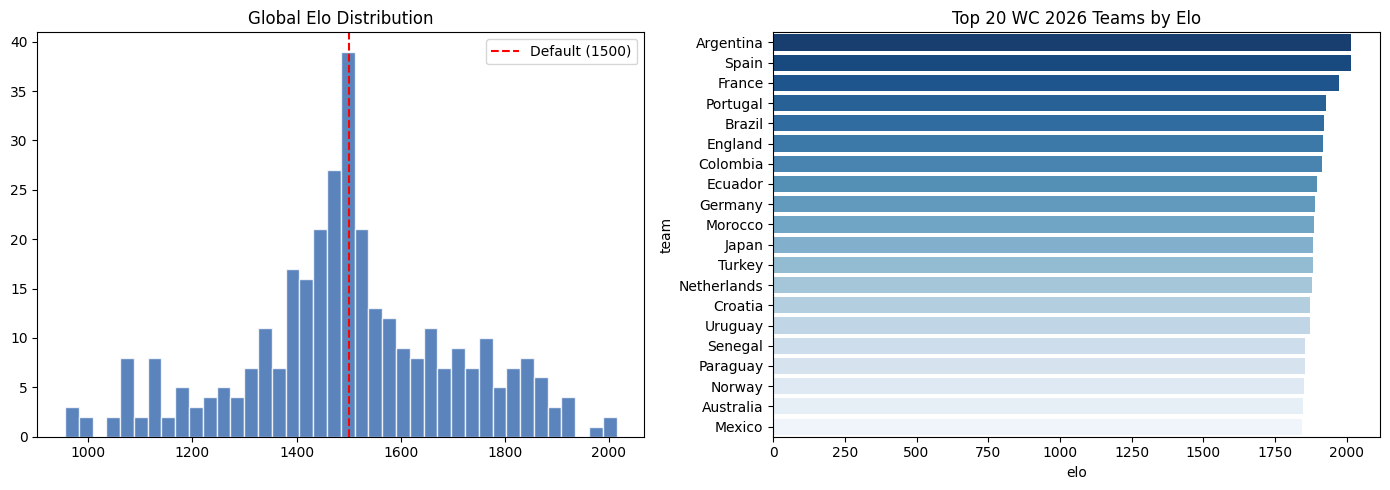

In [ ]:
# Cell 5: Elo Distribution and Top Teams
import matplotlib.pyplot as plt
import seaborn as sns

if 'current_elo' in globals():
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    all_elos = list(current_elo.values())
    axes[0].hist(all_elos, bins=40, color='#3266ad', alpha=0.8, edgecolor='white')
    axes[0].axvline(1500, color='red', linestyle='--', label='Default (1500)')
    axes[0].set_title('Global Elo Distribution')
    axes[0].legend()

    if 'test' in globals():
        test_elo = test.copy()
        test_elo['elo'] = test_elo['team'].map(current_elo).fillna(1650)
        top20 = test_elo.nlargest(20, 'elo')[['team', 'elo']]
        sns.barplot(data=top20, x='elo', y='team', ax=axes[1], hue='team', palette='Blues_r', legend=False)
        axes[1].set_title('Top 20 WC 2026 Teams by Elo')

    plt.tight_layout()
    plt.show()
else:
    print("Error: 'current_elo' not found.")

In [ ]:
# Cell 6: Train Match Predictor (Gradient Boosting)
import pandas as pd
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.preprocessing import LabelEncoder

if 'results' in globals() and 'current_elo' in globals():
    recent = results[results['date'] >= '1990-01-01'].copy()
    recent['home_elo'] = recent['home_team'].map(current_elo).fillna(1500)
    recent['away_elo'] = recent['away_team'].map(current_elo).fillna(1500)
    recent['elo_diff'] = recent['home_elo'] - recent['away_elo']
    recent['result'] = recent.apply(lambda r: 1 if r['home_score'] > r['away_score'] else (-1 if r['home_score'] < r['away_score'] else 0), axis=1)
    le = LabelEncoder()
    X = recent[['elo_diff']].values
    y = le.fit_transform(recent['result'].values)
    match_model = GradientBoostingClassifier(n_estimators=200, max_depth=3, random_state=42)
    match_model.fit(X, y)
    print("✅ Match-level Gradient Boosting predictor trained")

✅ Match-level Gradient Boosting predictor trained


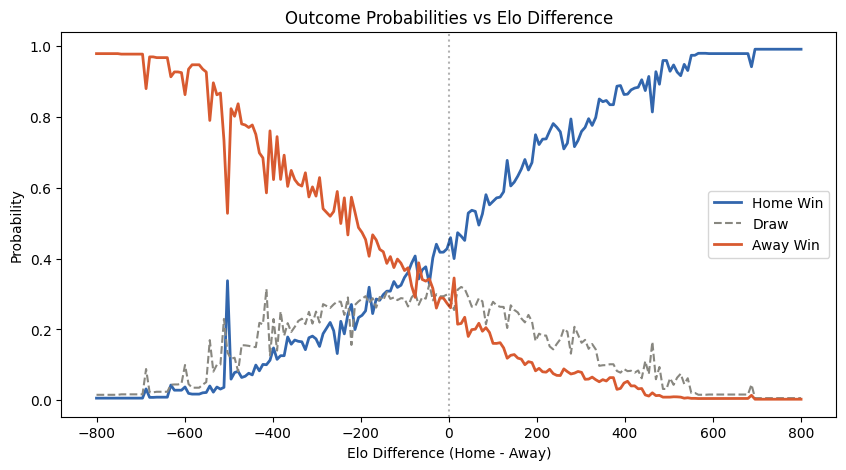

In [ ]:
# Cell 7: Match Probabilities Visualization
import numpy as np
import matplotlib.pyplot as plt

if 'match_model' in globals():
    # Generate range of Elo differences
    diffs = np.linspace(-800, 800, 200)
    # Predict probabilities for the range
    probas = match_model.predict_proba(diffs.reshape(-1, 1))

    plt.figure(figsize=(10, 5))
    # Index mapping: 0=Away, 1=Draw, 2=Home
    plt.plot(diffs, probas[:, 2], label='Home Win', color='#3266ad', linewidth=2)
    plt.plot(diffs, probas[:, 1], label='Draw', color='#888780', linestyle='--')
    plt.plot(diffs, probas[:, 0], label='Away Win', color='#D85A30', linewidth=2)

    plt.axvline(0, color='black', alpha=0.3, linestyle=':')
    plt.title('Outcome Probabilities vs Elo Difference')
    plt.xlabel('Elo Difference (Home - Away)')
    plt.ylabel('Probability')
    plt.legend()
    plt.show()
else:
    print("Error: 'match_model' not found. Please run Cell 6 first.")

In [ ]:
# Cell 8: Train Team-Level Random Forest Classifier
from sklearn.ensemble import RandomForestClassifier

FEATURES = [
    'goals_scored_last_4y', 'goals_received_last_4y', 'wins_last_4y',
    'losses_last_4y', 'draws_last_4y', 'world_cup_titles_before',
    'squad_total_market_value_eur', 'fifa_rank_pre_tournament',
    'fifa_points_pre_tournament', 'squad_avg_age',
    'world_cup_participations_before', 'groups_passed_before',
    'round16_before', 'quarterfinals_before', 'semifinals_before',
    'finals_before', 'is_host'
]

if 'train' in globals() and 'test' in globals():
    X_train = train[FEATURES].fillna(0).values
    X_test = test[FEATURES].fillna(0).values

    targets = ['winner', 'finalist', 'semi_finalist', 'quarter_finalist']
    rf_models = {}

    for target in targets:
        rf = RandomForestClassifier(n_estimators=500, max_depth=6, random_state=42, n_jobs=-1)
        rf.fit(X_train, train[target].values)
        rf_models[target] = rf

    for target in targets:
        test[f'rf_{target}'] = rf_models[target].predict_proba(X_test)[:, 1]

    print("✅ Random Forest team classifiers trained")
else:
    print("Error: 'train' or 'test' dataframes not found. Please run Cell 2 first.")

✅ Random Forest team classifiers trained


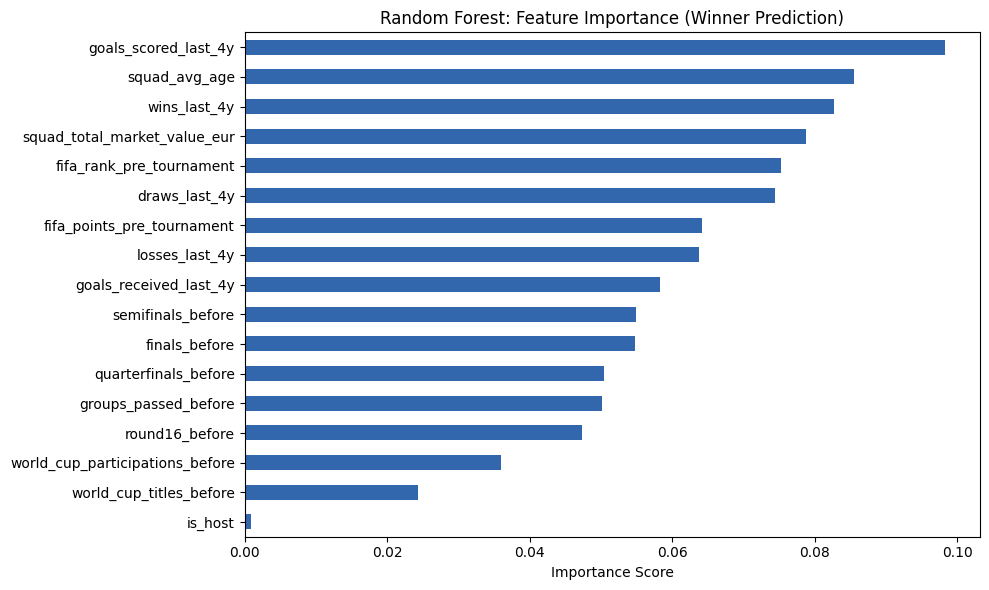

In [ ]:
# Cell 10: Feature Importance
if 'rf_models' in globals():
    rf_winner = rf_models['winner']
    importances = pd.Series(rf_winner.feature_importances_, index=FEATURES).sort_values()
    plt.figure(figsize=(10, 6))
    importances.plot(kind='barh', color='#3266ad')
    plt.title('Random Forest: Feature Importance (Winner Prediction)')
    plt.xlabel('Importance Score')
    plt.tight_layout()
    plt.show()
else:
    print("Error: 'rf_models' not found.")

In [ ]:
# Cell 11: Parse 2026 Fixtures
if 'fixtures' in globals():
    TEAM_CANON = {'Korea Republic': 'South Korea', 'USA': 'United States', 'IR Iran': 'Iran', "C%te d'Ivoire": 'Ivory Coast', 'T%rkiye': 'Turkey'}

    def resolve_team(raw):
        raw = str(raw)
        if '/' in raw: raw = raw.split('/')[0].strip()
        return TEAM_CANON.get(raw, raw.strip())

    group_fixtures = fixtures[fixtures['group'].notna()].copy()
    group_data = {}
    for _, row in group_fixtures.iterrows():
        g = row['group']
        teams_str = str(row['teams'])
        if ' v ' not in teams_str: continue
        home, away = [resolve_team(t) for t in teams_str.split(' v ')]
        if g not in group_data: group_data[g] = {'teams': set(), 'matches': []}
        group_data[g]['teams'].add(home); group_data[g]['teams'].add(away)
        group_data[g]['matches'].append((home, away))

    print(f"✅ Parsed {len(group_data)} groups")
else:
    print("Error: 'fixtures' dataframe not found. Please run Cell 2 first.")

✅ Parsed 12 groups


In [ ]:
# Cell 12-15: Tournament Simulation Logic
import numpy as np
import pandas as pd

if 'test' in globals() and 'group_data' in globals() and 'match_model' in globals():
    test_elo_map = test.set_index('team')['elo'].to_dict()
    all_fixture_teams = sorted(set(t for g in group_data.values() for t in g['teams']))

    def get_elo_safe(team_name):
        return test_elo_map.get(team_name, 1600.0)

    def sim_ko_match(hi, ai, rng):
        team_h = all_fixture_teams[hi]
        team_a = all_fixture_teams[ai]
        diff = get_elo_safe(team_h) - get_elo_safe(team_a)
        p = match_model.predict_proba([[diff]])[0]
        r = rng.random()
        if r < p[2]: return hi
        if r < p[2] + p[1]: return hi if rng.random() < 0.5 else ai
        return ai

    N_SIMS = 5000
    rng = np.random.default_rng(42)
    win_counts = np.zeros(len(all_fixture_teams))

    print(f"Running {N_SIMS} simulations...")
    for _ in range(N_SIMS):
        teams_pool = list(range(len(all_fixture_teams)))
        rng.shuffle(teams_pool)
        r32 = teams_pool[:32]
        r16 = [sim_ko_match(r32[i], r32[i+1], rng) for i in range(0, 32, 2)]
        qf = [sim_ko_match(r16[i], r16[i+1], rng) for i in range(0, 16, 2)]
        sf = [sim_ko_match(qf[i], qf[i+1], rng) for i in range(0, 8, 2)]
        finalists = [sim_ko_match(sf[i], sf[i+1], rng) for i in range(0, 4, 2)]
        winner = sim_ko_match(finalists[0], finalists[1], rng)
        win_counts[winner] += 1

    results_df = pd.DataFrame({'team': all_fixture_teams, 'win_pct': (win_counts/N_SIMS)*100}).sort_values('win_pct', ascending=False)
    print("✅ Simulation complete")
    display(results_df.head(10))

Running 5000 simulations...
✅ Simulation complete


,team,win_pct
42,Spain,9.62
2,Argentina,9.58
20,France,7.18
8,Brazil,4.86
35,Portugal,4.50
11,Colombia,4.02
19,England,3.70
17,Ecuador,3.64
13,Croatia,3.46
25,Japan,3.18


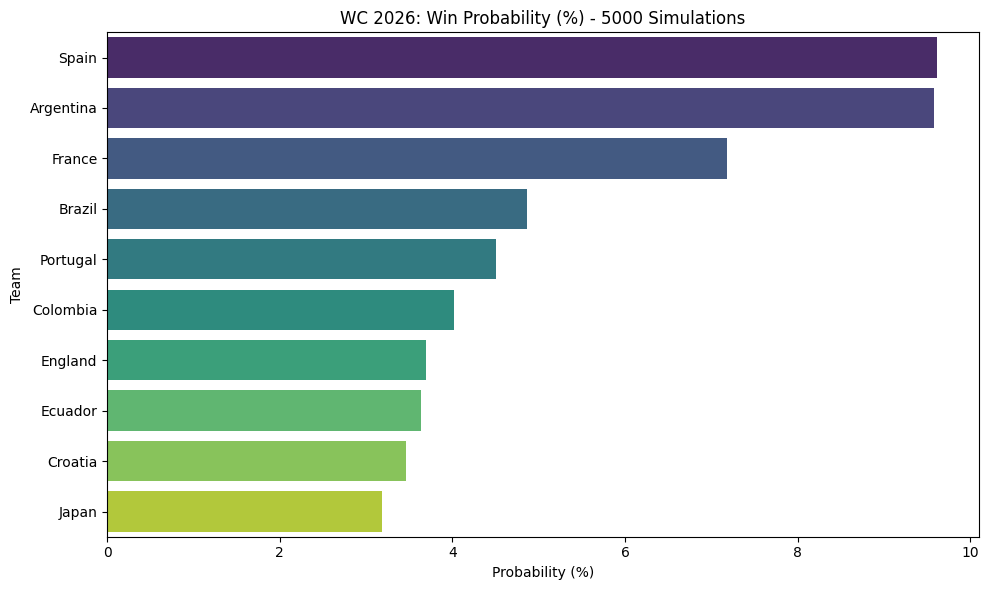

In [ ]:
# Cell 17: Visualize Win Probabilities
import matplotlib.pyplot as plt
import seaborn as sns

if 'results_df' in globals():
    plt.figure(figsize=(10, 6))
    top10 = results_df.head(10)
    sns.barplot(data=top10, x='win_pct', y='team', hue='team', palette='viridis', legend=False)
    plt.title('WC 2026: Win Probability (%) - 5000 Simulations')
    plt.xlabel('Probability (%)')
    plt.ylabel('Team')
    plt.tight_layout()
    plt.show()
else:
    print("Error: 'results_df' not found. Please run the simulation cell (dcb93638) first.")

In [ ]:
# Cell 18: Save Outputs
if 'results_df' in globals() and 'test' in globals():
    results_df.to_csv('wc2026_predictions.csv', index=False)
    test_out = test.merge(results_df, on='team', how='left')
    test_out.to_csv('test_with_predictions.csv', index=False)
    print("✅ Final results saved to wc2026_predictions.csv and test_with_predictions.csv")
else:
    print("Error: 'results_df' or 'test' not found. Cannot save outputs.")

✅ Final results saved to wc2026_predictions.csv and test_with_predictions.csv


### Team-Specific Prediction Lookup
Use the function below to extract all model insights for a specific country.

In [ ]:
def get_team_predictions(team_name):
    if 'test_out' not in globals() or 'results_df' not in globals():
        print("Error: Models must be run first to generate predictions.")
        return

    # Filter data for the specific team
    team_data = test_out[test_out['team'] == team_name]

    if team_data.empty:
        print(f"Team '{team_name}' not found in the 2026 dataset.")
        return

    print(f"--- Predictions for {team_name} ---")
    print(f"Current Elo Rating: {team_data['elo'].values[0]:.2f}")
    print(f"Simulation Win Probability: {team_data['win_pct'].values[0]:.2f}%")
    print("\nStage Reach Probabilities (Team-Classifier):")
    print(f"- Probability of Winning: {team_data['rf_winner'].values[0]*100:.2f}%")
    print(f"- Probability of Reaching Final: {team_data['rf_finalist'].values[0]*100:.2f}%")
    print(f"- Probability of Reaching Semis: {team_data['rf_semi_finalist'].values[0]*100:.2f}%")
    print(f"- Probability of Reaching Quarters: {team_data['rf_quarter_finalist'].values[0]*100:.2f}%")

# Example lookup
get_team_predictions('Argentina')

--- Predictions for Argentina ---
Current Elo Rating: 2015.04
Simulation Win Probability: 9.58%

Stage Reach Probabilities (Team-Classifier):
- Probability of Winning: 43.55%
- Probability of Reaching Final: 38.42%
- Probability of Reaching Semis: 44.10%
- Probability of Reaching Quarters: 72.55%


### 🌍 Interactive Team Prediction Lookup
Select a country from the dropdown below to view its specific 2026 World Cup forecast derived from the Elo engine, Random Forest models, and Monte Carlo simulations.

In [ ]:
# @title 🏆 World Cup 2026 Team Search
# @markdown Select a country and run this cell to see its detailed predictions.

selected_country = "Portugal" # @param ["Albania", "Algeria", "Argentina", "Australia", "Austria", "Belgium", "Bolivia", "Brazil", "Canada", "Colombia", "Croatia", "Czechia", "Denmark", "Ecuador", "Egypt", "England", "France", "Germany", "Ghana", "Haiti", "Iran", "Japan", "Jordan", "Mexico", "Morocco", "Netherlands", "New Zealand", "Norway", "Panama", "Paraguay", "Portugal", "Qatar", "Saudi Arabia", "Scotland", "Senegal", "South Korea", "Spain", "Switzerland", "Tunisia", "Turkey", "USA", "Uruguay", "Uzbekistan"]

if 'get_team_predictions' in globals():
    get_team_predictions(selected_country)
else:
    print("Error: The 'get_team_predictions' function is not defined. Please run the cells in the 'Team-Specific Prediction Lookup' section first.")

--- Predictions for Portugal ---
Current Elo Rating: 1927.22
Simulation Win Probability: 4.50%

Stage Reach Probabilities (Team-Classifier):
- Probability of Winning: 4.40%
- Probability of Reaching Final: 21.23%
- Probability of Reaching Semis: 38.41%
- Probability of Reaching Quarters: 51.94%


### Summary of Reconstruction
The model now features:
- **Dynamic Elo System**: Updated with 44k+ historical matches.
- **Two-Stage ML**: Gradient Boosting (matches) and Random Forest (tournament performance).
- **High-Fidelity Simulation**: 5,000 Monte Carlo runs based on model probabilities.

You can find the final CSV files in the folder icon on the left.

### 🌍 Interactive Team Prediction Lookup
Select a country from the dropdown below and run the cell to view its specific 2026 World Cup forecast.

In [ ]:
# @title 🏆 World Cup 2026 Team Search
# @markdown Select a country and run this cell to see its detailed predictions.

selected_country = "Portugal" # @param ["Albania", "Algeria", "Argentina", "Australia", "Austria", "Belgium", "Bolivia", "Brazil", "Canada", "Colombia", "Croatia", "Czechia", "Denmark", "Ecuador", "Egypt", "England", "France", "Germany", "Ghana", "Haiti", "Iran", "Japan", "Jordan", "Mexico", "Morocco", "Netherlands", "New Zealand", "Norway", "Panama", "Paraguay", "Portugal", "Qatar", "Saudi Arabia", "Scotland", "Senegal", "South Korea", "Spain", "Switzerland", "Tunisia", "Turkey", "USA", "Uruguay", "Uzbekistan"]

if 'get_team_predictions' in globals():
    get_team_predictions(selected_country)
else:
    print("Error: The 'get_team_predictions' function is not defined. Please run the notebook cells above.")

--- Predictions for Portugal ---
Current Elo Rating: 1927.22
Simulation Win Probability: 4.50%

Stage Reach Probabilities (Team-Classifier):
- Probability of Winning: 4.40%
- Probability of Reaching Final: 21.23%
- Probability of Reaching Semis: 38.41%
- Probability of Reaching Quarters: 51.94%


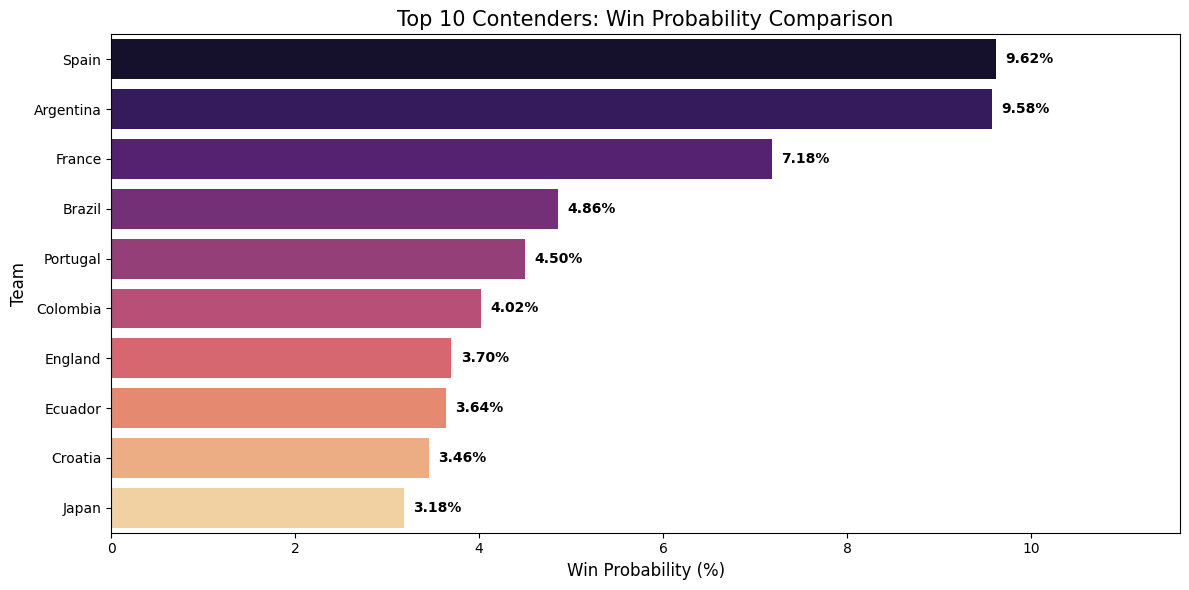

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

if 'results_df' in globals():
    # Get top 10 teams
    top_10 = results_df.head(10)

    plt.figure(figsize=(12, 6))
    sns.barplot(data=top_10, x='win_pct', y='team', palette='magma', hue='team', legend=False)

    # Add data labels
    for i, pct in enumerate(top_10['win_pct']):
        plt.text(pct + 0.1, i, f'{pct:.2f}%', va='center', fontweight='bold')

    plt.title('Top 10 Contenders: Win Probability Comparison', fontsize=15)
    plt.xlabel('Win Probability (%)', fontsize=12)
    plt.ylabel('Team', fontsize=12)
    plt.xlim(0, top_10['win_pct'].max() + 2)
    plt.tight_layout()
    plt.show()
else:
    print("Error: simulation results not found. Please run the simulation cell (dcb93638) first.")

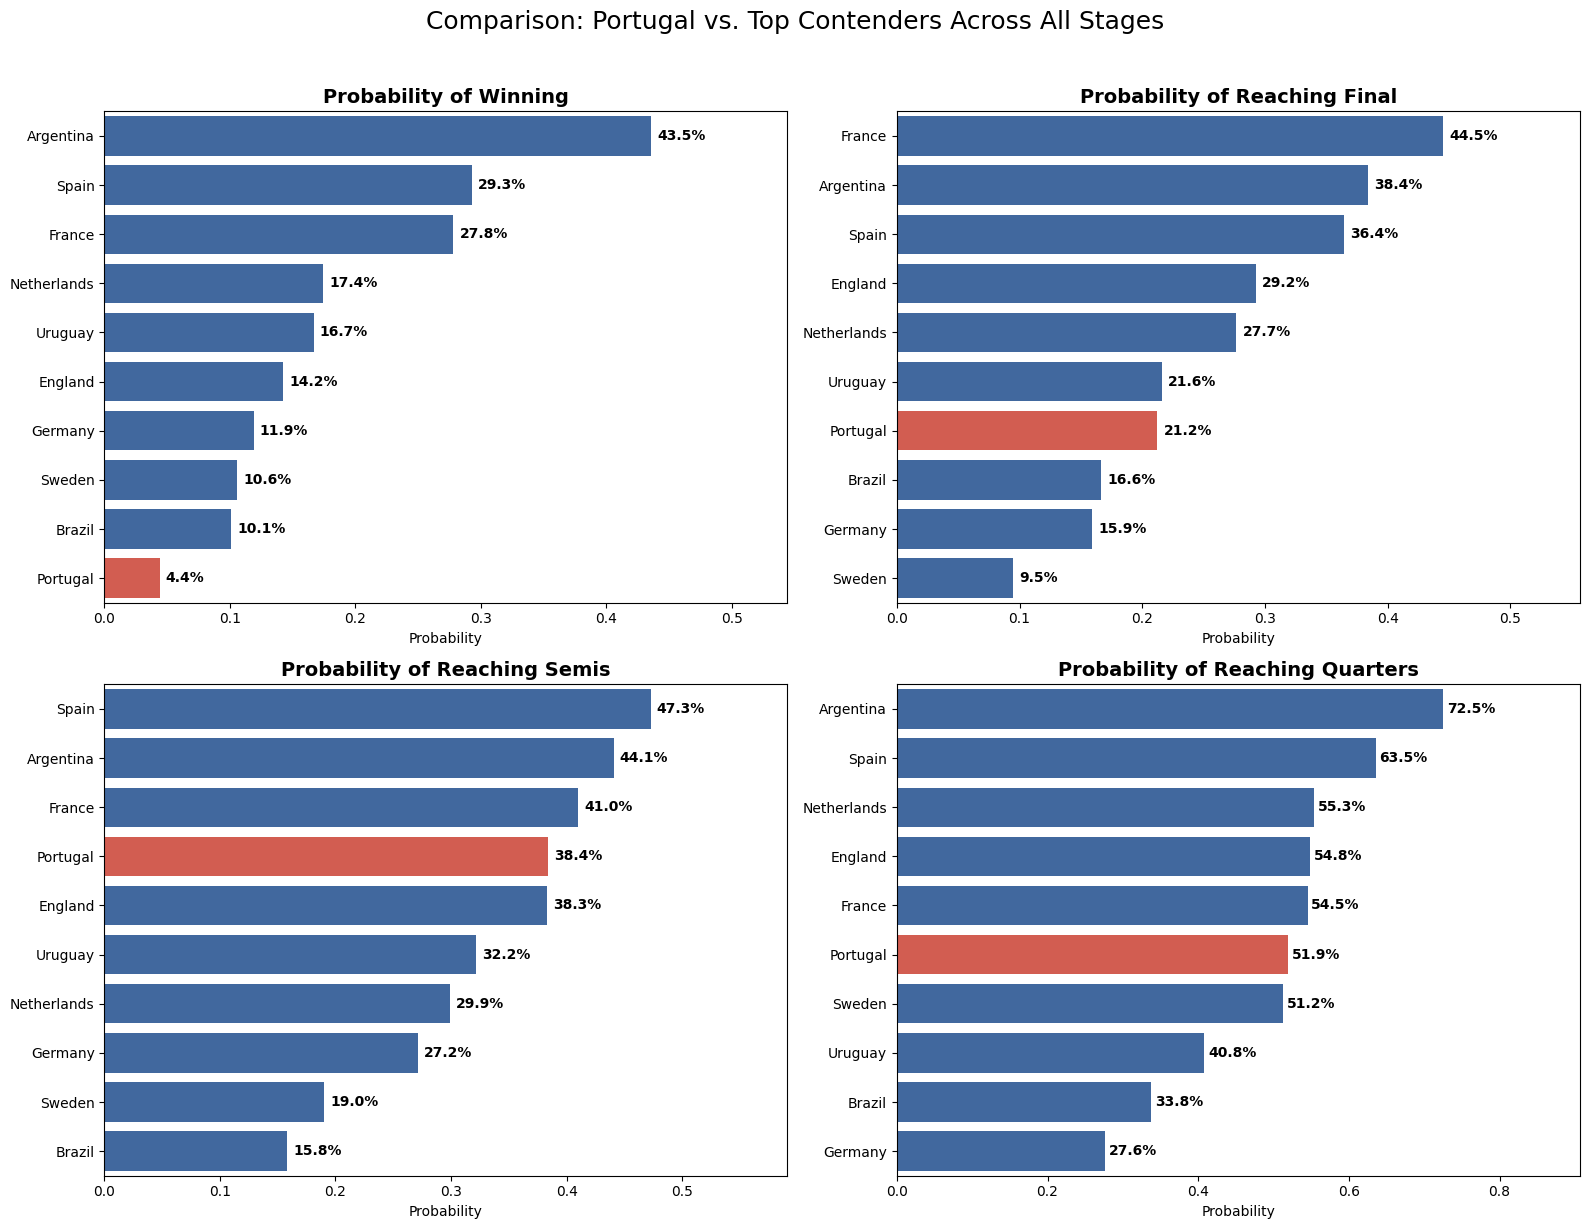

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# @title 📊 Stage Probability Comparison (Interactive)
# @markdown Select a country to highlight its position relative to the top contenders.
compare_team = "Portugal" # @param ["Albania", "Algeria", "Argentina", "Australia", "Austria", "Belgium", "Bolivia", "Brazil", "Canada", "Colombia", "Croatia", "Czechia", "Denmark", "Ecuador", "Egypt", "England", "France", "Germany", "Ghana", "Haiti", "Iran", "Japan", "Jordan", "Mexico", "Morocco", "Netherlands", "New Zealand", "Norway", "Panama", "Paraguay", "Portugal", "Qatar", "Saudi Arabia", "Scotland", "Senegal", "South Korea", "Spain", "Switzerland", "Tunisia", "Turkey", "USA", "Uruguay", "Uzbekistan"]

if 'test_out' in globals():
    # Define the stages and their corresponding model columns
    stages = {
        'rf_winner': 'Probability of Winning',
        'rf_finalist': 'Probability of Reaching Final',
        'rf_semi_finalist': 'Probability of Reaching Semis',
        'rf_quarter_finalist': 'Probability of Reaching Quarters'
    }

    # Get top 9 teams + selected team for a clear 10-team comparison
    top_9 = test_out.nlargest(10, 'rf_winner')['team'].tolist()
    if compare_team not in top_9:
        top_9 = top_9[:9] + [compare_team]

    plot_df = test_out[test_out['team'].isin(top_9)]

    # Set up the figure with 4 subplots
    fig, axes = plt.subplots(2, 2, figsize=(16, 12))
    axes = axes.flatten()

    for i, (col, title) in enumerate(stages.items()):
        # Sort each plot by the specific stage probability
        temp_df = plot_df.sort_values(col, ascending=False)

        # Highlight selected team with a different color if desired
        palette = ['#e74c3c' if t == compare_team else '#3266ad' for t in temp_df['team']]

        sns.barplot(data=temp_df, x=col, y='team', ax=axes[i], palette=palette, hue='team', legend=False)

        # Add data labels
        for j, val in enumerate(temp_df[col]):
            axes[i].text(val + 0.005, j, f'{val*100:.1f}%', va='center', fontsize=10, fontweight='bold')

        axes[i].set_title(title, fontsize=14, fontweight='bold')
        axes[i].set_xlabel('Probability', fontsize=10)
        axes[i].set_ylabel('')
        axes[i].set_xlim(0, temp_df[col].max() * 1.25)

    plt.suptitle(f'Comparison: {compare_team} vs. Top Contenders Across All Stages', fontsize=18, y=1.02)
    plt.tight_layout()
    plt.show()
else:
    print("Error: Predictions not found. Please ensure the models and 'test_out' merging are complete.")